# **Progetto Data Mining - Sistema di Raccomandazione (Book-Crossing)**
#### **Studente**: Francesco Salvatore Merlo
#### **Matricola**: 250395

---

## Descrizione del Progetto

L'obiettivo di questo progetto è sviluppare un **Recommender System** in grado di suggerire libri personalizzati agli utenti basandosi sulle similarità dei loro gusti (Collaborative Filtering).
Il dataset utilizzato è "Book-Crossing", composto da anagrafiche utenti, metadati dei libri e valutazioni.

A causa dell'elevata "sparsità" tipica di questi dataset, il progetto implementa una pipeline di pulizia rigorosa (K-Core filtering) e utilizza la tecnica di fattorizzazione matriciale **SVD (Singular Value Decomposition)** per prevedere i voti nascosti.

---
# Fase 1: Lettura dei dati
Vengono caricati i tre dataset principali (Users, Books, Ratings) e viene eseguita una forzatura sulle intestazioni delle colonne per correggere eventuali disallineamenti nei file CSV grezzi.

In [5]:
import pandas as pd

print("⏳ Caricamento dei file CSV in corso...")
users = pd.read_csv('Users.csv', sep=';', encoding='latin-1', on_bad_lines='skip')
books = pd.read_csv('Books.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)
ratings = pd.read_csv('Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip')

# Forzatura colonne
ratings.columns = ['UserID', 'ISBN', 'BookRating']
books.columns = ['ISBN', 'BookTitle', 'BookAuthor', 'YearOfPublication', 'Publisher']
users.rename(columns={'User-ID': 'UserID'}, inplace=True)

print(f"Record Valutazioni iniziali: {ratings.shape[0]}")
print(f"Record Libri iniziali: {books.shape[0]}")
display(ratings.head(3))

⏳ Caricamento dei file CSV in corso...


C:\Users\merlo\AppData\Local\Temp\ipykernel_16268\3126863737.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv('Users.csv', sep=';', encoding='latin-1', on_bad_lines='skip')


Record Valutazioni iniziali: 1149780
Record Libri iniziali: 271379


,UserID,ISBN,BookRating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


# Fase 2: Pre-Processing e Filtraggio K-Core

Per ottimizzare le performance, rimuoviamo i feedback impliciti (voti = 0) e applichiamo un **K-Core Filtering (Soglia 20)**: manteniamo solo gli utenti e i libri con almeno 20 recensioni.

In [6]:
# 1. Rimozione dei feedback impliciti
explicit_ratings = ratings[ratings['BookRating'] != 0]

# 2. K-Core Filtering: Utenti (min 10 recensioni)
valid_users = explicit_ratings['UserID'].value_counts()[explicit_ratings['UserID'].value_counts() >= 10].index
filtered_ratings = explicit_ratings[explicit_ratings['UserID'].isin(valid_users)]

# 3. K-Core Filtering: Libri (min 10 recensioni)
valid_books = filtered_ratings['ISBN'].value_counts()[filtered_ratings['ISBN'].value_counts() >= 10].index
final_ratings = filtered_ratings[filtered_ratings['ISBN'].isin(valid_books)]

print("=== STATISTICHE DOPO IL PRE-PROCESSING (Soglia 10) ===")
print(f"Rating utili per l'addestramento: {final_ratings.shape[0]}")
print(f"Utenti unici rimasti: {final_ratings['UserID'].nunique()}")
print(f"Libri nel catalogo filtrato: {final_ratings['ISBN'].nunique()}")


=== STATISTICHE DOPO IL PRE-PROCESSING (Soglia 10) ===
Rating utili per l'addestramento: 74907
Utenti unici rimasti: 6570
Libri nel catalogo filtrato: 3411


# Fase 2.5: Visualizzazione Grafica e Analisi Dati

Per comprendere meglio l'impatto della pulizia dei dati, visualizziamo due metriche fondamentali tramite grafici a torta:
1. **Tipologia di Valutazioni:** La proporzione tra voti impliciti (pari a 0, non utili per l'SVD) e voti espliciti (da 1 a 10).
2. **Impatto del K-Core:** La percentuale di dati scartati rispetto a quelli mantenuti applicando il filtro a 10 recensioni, dimostrando come il dataset venga snellito dai profili inattivi.

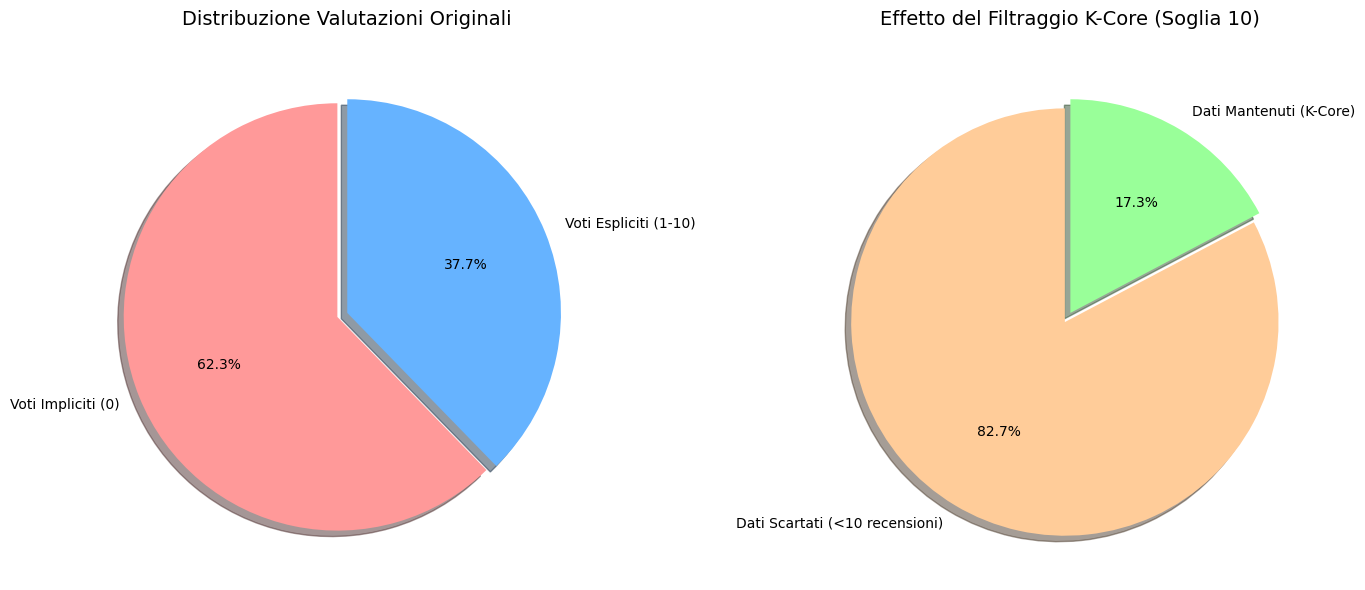

In [7]:
import matplotlib.pyplot as plt

# --- PREPARAZIONE DATI ---
# Dati per il Grafico 1: Impliciti vs Espliciti
voti_impliciti = ratings[ratings['BookRating'] == 0].shape[0]
voti_espliciti = explicit_ratings.shape[0]

# Dati per il Grafico 2: Impatto del K-Core
dati_mantenuti = final_ratings.shape[0]
dati_scartati = explicit_ratings.shape[0] - dati_mantenuti

# --- CREAZIONE DEI GRAFICI A TORTA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1
ax1.pie([voti_impliciti, voti_espliciti], labels=['Voti Impliciti (0)', 'Voti Espliciti (1-10)'], 
        autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'], explode=(0.05, 0), shadow=True)
ax1.set_title("Distribuzione Valutazioni Originali", fontsize=14, pad=15)

# Grafico 2
ax2.pie([dati_scartati, dati_mantenuti], labels=['Dati Scartati (<10 recensioni)', 'Dati Mantenuti (K-Core)'], 
        autopct='%1.1f%%', startangle=90, colors=['#ffcc99','#99ff99'], explode=(0.05, 0), shadow=True)
ax2.set_title("Effetto del Filtraggio K-Core (Soglia 10)", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# Fase 3: Ottimizzazione degli Iperparametri (Grid Search)

Prima di addestrare il modello finale, utilizziamo la tecnica della **Grid Search** combinata con la Cross-Validation. Questo ci permette di testare diverse combinazioni di "iperparametri" (epoche di addestramento, learning rate e regolarizzazione) per trovare quella che minimizza matematicamente l'errore RMSE sul nostro dataset specifico, evitando l'overfitting.

In [8]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import GridSearchCV

print("⏳ Configurazione del formato Surprise...")
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(final_ratings[['UserID', 'ISBN', 'BookRating']], reader)

print("⏳ Avvio Grid Search per l'ottimizzazione dei parametri...")
print("   [Attenzione: testerà varie combinazioni, potrebbe richiedere un minuto]\n")

# Definiamo una griglia di parametri da testare
param_grid = {
    'n_epochs': [10, 20],        # Numero di iterazioni
    'lr_all': [0.002, 0.005],    # Learning rate (velocità di apprendimento)
    'reg_all': [0.02, 0.1]       # Termine di regolarizzazione
}

# Eseguiamo la Grid Search con 3-Fold Cross Validation
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

print("✅ RICERCA COMPLETATA!")
print(f"📊 Miglior RMSE ottenuto: {gs.best_score['rmse']:.4f}")
print(f"⚙️ Parametri ottimali trovati: {gs.best_params['rmse']}")

# Salviamo il modello ottimizzato per usarlo nella fase successiva
algo_ottimizzato = gs.best_estimator['rmse']

⏳ Configurazione del formato Surprise...
⏳ Avvio Grid Search per l'ottimizzazione dei parametri...
   [Attenzione: testerà varie combinazioni, potrebbe richiedere un minuto]

✅ RICERCA COMPLETATA!
📊 Miglior RMSE ottenuto: 1.5652
⚙️ Parametri ottimali trovati: {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}


# Fase 4: Addestramento SVD

Il modello SVD viene istanziato, valutato tramite **5-Fold Cross-Validation** (per calcolare RMSE e MAE) e infine addestrato sull'intero dataset per l'utilizzo pratico.

In [9]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate

print("⏳ Configurazione del formato Surprise...")
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(final_ratings[['UserID', 'ISBN', 'BookRating']], reader)

algo = SVD()

print("⏳ Avvio Cross-Validation (5 pieghe)...\n")
results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

trainset = data.build_full_trainset()
algo.fit(trainset)
print("\n✅ ADDESTRAMENTO COMPLETATO CON SUCCESSO!")

⏳ Configurazione del formato Surprise...
⏳ Avvio Cross-Validation (5 pieghe)...

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.5465  1.5578  1.5727  1.5518  1.5809  1.5620  0.0129  
MAE (testset)     1.1975  1.1928  1.2073  1.1974  1.2090  1.2008  0.0063  
Fit time          1.04    1.15    1.01    1.00    1.17    1.07    0.07    
Test time         0.12    0.22    0.10    0.17    0.10    0.14    0.04    

✅ ADDESTRAMENTO COMPLETATO CON SUCCESSO!


# Fase 5: Motore Interattivo Top 10 e Conclusioni

La funzione finale analizza i libri non letti dall'utente target, prevede i voti e stampa la classifica personalizzata.

In [10]:
def genera_top_10(user_id, algo, final_ratings, books_df):
    print(f"\n🔄 Calcolo raccomandazioni per l'utente {user_id}...")
    libri_letti = final_ratings[final_ratings['UserID'] == user_id]['ISBN'].unique()
    tutti_i_libri = final_ratings['ISBN'].unique()
    libri_da_valutare = [libro for libro in tutti_i_libri if libro not in libri_letti]
    
    predizioni = [algo.predict(uid=user_id, iid=libro) for libro in libri_da_valutare]
    predizioni.sort(key=lambda x: x.est, reverse=True)
    top_10 = predizioni[:10]
    
    print(f"\n🏆 TOP 10 LIBRI CONSIGLIATI PER L'UTENTE {user_id} 🏆")
    print("-" * 85)
    print(f"{'POS':<5} | {'TITOLO':<40} | {'AUTORE':<15} | {'VOTO STIMATO'}")
    print("-" * 85)
    
    for i, pred in enumerate(top_10, 1):
        dettagli = books_df[books_df['ISBN'] == pred.iid]
        if not dettagli.empty:
            titolo = str(dettagli['BookTitle'].values[0])[:37] + "..." if len(str(dettagli['BookTitle'].values[0])) > 40 else str(dettagli['BookTitle'].values[0])
            autore = str(dettagli['BookAuthor'].values[0])[:12] + "..." if len(str(dettagli['BookAuthor'].values[0])) > 15 else str(dettagli['BookAuthor'].values[0])
            print(f"{i:<5} | {titolo:<40} | {autore:<15} | ⭐ {pred.est:.2f} / 10")
        else:
            print(f"{i:<5} | Dettagli non trovati (ISBN: {pred.iid}) |                 | ⭐ {pred.est:.2f} / 10")

# --- TEST ---
# Selezioniamo in automatico il primo utente valido per dimostrazione
utente_test = final_ratings['UserID'].value_counts().index[0]
genera_top_10(utente_test, algo, final_ratings, books)

print("""
\n[CONSIDERAZIONI FINALI]
- Il filtraggio K-Core garantisce stabilità all'algoritmo SVD riducendo l'errore medio (MAE).
- La gestione dei Dati Mancanti previene crash causati da disallineamenti tra i CSV originali.
""")


🔄 Calcolo raccomandazioni per l'utente 11676...

🏆 TOP 10 LIBRI CONSIGLIATI PER L'UTENTE 11676 🏆
-------------------------------------------------------------------------------------
POS   | TITOLO                                   | AUTORE          | VOTO STIMATO
-------------------------------------------------------------------------------------
1     | Harry Potter and the Prisoner of Azka... | J. K. Rowling   | ⭐ 10.00 / 10
2     | The Giving Tree                          | Shel Silvers... | ⭐ 10.00 / 10
3     | The Diving Bell and the Butterfly : A... | JEAN-DOMINIQ... | ⭐ 9.88 / 10
4     | It's A Magical World: A Calvin and Ho... | Bill Watterson  | ⭐ 9.87 / 10
5     | Life,the Universe and Everything         | Douglas Adams   | ⭐ 9.83 / 10
6     | Dilbert: A Book of Postcards             | Scott Adams     | ⭐ 9.78 / 10
7     | The Grapes of Wrath                      | John Steinbeck  | ⭐ 9.77 / 10
8     | Harry Potter and the Chamber of Secre... | J. K. Rowling   | ⭐ 9.74 / 1